# STEP 9. H2 · 보조질문 2 마무리

여기서 두 질문에 최종 답을 냅니다. **자치구 × 업종 예측표는 만들지 않습니다** — 핵심 질문에 답하는 산출물이라 우리 범위가 아닙니다.

## 다루는 것

| 절 | 하는 일 | 어느 질문 |
|---|---|---|
| 9-1 | 반사실 시뮬레이션 — 값을 강제로 맞추면 격차가 어떻게 되나 | **H2** |
| 9-2 | 라벨의 산술 진단 — "규모가 위험하다"는 게 진짜인가 | **보조질문 2** ★ |
| 9-3 | 유동인구는 왜 무관했나 | **보조질문 2** |
| 9-4 | 대안 라벨로 H2 재검증 | **H2** 강건성 |
| 9-5 | 최종 종합 | 둘 다 |

## 9-1 이 하는 일

STEP 6 의 PSM 은 **짝을 지어** 조건을 맞췄습니다. 여기서는 STEP 8 의 예측 모형을 써서 **값을 강제로 바꿔** 같은 실험을 합니다.

1. 학습된 모형은 그대로 두고
2. 골목상권 데이터를 복사한 뒤 특정 변수만 전부 같은 값(중앙값)으로 바꾸고
3. 그 가짜 데이터로 예측 확률을 다시 뽑아
4. 한식과 대조군의 **예측 격차**가 어떻게 변하는지 봅니다

"모든 칸이 같은 규모라면 어떻게 될까"를 모형에게 묻는 것입니다. 매칭이 짝짓기로 한 일을 모형이 값 치환으로 합니다. **두 방법이 같은 답을 내면 결론이 방법에 의존하지 않는다**는 강한 증거가 됩니다.


In [2]:
import sys, os
from pathlib import Path

# 노트북이 어디서 열리든 프로젝트 루트를 찾아 sys.path에 추가
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

# config.py 를 고친 뒤 커널을 재시작하지 않으면 파이썬이 옛 모듈을 캐시한다.
import importlib
if "config" in sys.modules:
    importlib.reload(sys.modules["config"])

import numpy as np
import pandas as pd
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
print("프로젝트 루트:", ROOT)

프로젝트 루트: c:\Users\spide\ai-data-bootcamp\project\h2_nb


In [3]:
import pickle
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from config import (PROC, FIG, TARGET_TYPE, TREAT_SVC, COVARIATES, TRAIN_QUARTERS,
                    build_features, design_matrix, set_korean_font)
set_korean_font()
OUT = FIG.parent
SEED, B_BOOT = 42, 300

with open(PROC / "08_model.pkl", "rb") as f:
    bundle = pickle.load(f)
MODEL, COLS = bundle["model"], bundle["columns"]
print(f"STEP 8 모형 : {bundle['model_name']} | 피처 {len(COLS)}개")
print(f"검증 성능   : AUC {bundle['valid_metrics']['AUC']:.3f}")

panel = build_features(pd.read_pickle(PROC / "03_panel.pkl"))
gm = panel[(panel["상권유형"] == TARGET_TYPE) &
           (panel["기준_년분기_코드"].isin(TRAIN_QUARTERS))].copy()
gm["처리"] = (gm["서비스_업종_코드_명"] == TREAT_SVC).astype(int)
T = gm["처리"].to_numpy() == 1
print(f"\n{TARGET_TYPE} 학습 분기 {len(gm):,}행 | 처리군 {T.sum():,} / 대조군 {(~T).sum():,}")

STEP 8 모형 : E 부스팅 | 피처 51개
검증 성능   : AUC 0.669

골목상권 학습 분기 31,875행 | 처리군 9,129 / 대조군 22,746


### 상류 단계의 값 불러오기

STEP 6·7 이 낸 수치를 **파일에서 읽어옵니다.** 여기에 숫자를 적어 두면 상류를 다시 돌렸을 때 이 문서만 옛 값을 인쇄하게 됩니다 — 실제로 그런 일이 한 번 있었습니다.

In [4]:
_att = pd.read_csv(OUT / "h2_att.csv")
ATT6      = float(_att["ATT"].iloc[0])            # STEP 6 매칭 ATT
GAP_RAW   = float(_att["매칭전_격차"].iloc[0])     # STEP 5 단순 격차
ATT_DR    = float(pd.read_csv(OUT / "h2_att_dr.csv")["이중강건_ATT"].iloc[0])
print(f"STEP 5 단순 격차   {GAP_RAW:+.2%}p")
print(f"STEP 6 매칭 ATT    {ATT6:+.2%}p")
print(f"STEP 7 이중강건    {ATT_DR:+.2%}p")

STEP 5 단순 격차   +2.38%p
STEP 6 매칭 ATT    -5.76%p
STEP 7 이중강건    -6.14%p


## 9-1. 반사실 시뮬레이션

`predict_gap()` 은 지정한 변수들을 전부 중앙값으로 바꾼 뒤 예측 격차를 계산합니다. 신뢰구간은 **상권 단위 클러스터 부트스트랩**으로 냅니다 (같은 상권이 11분기 반복 관측되므로).

In [5]:
areas = gm["상권_코드"].to_numpy()
uniq  = np.unique(areas)
pos   = {u: np.where(areas == u)[0] for u in uniq}
rng   = np.random.default_rng(SEED)
BOOT_IDX = [np.concatenate([pos[u] for u in rng.choice(uniq, len(uniq), replace=True)])
            for _ in range(B_BOOT)]

def predict_gap(fix=(), frame=None):
    """fix 에 든 변수를 중앙값으로 고정하고 예측 격차와 95% CI 를 반환"""
    f = (gm if frame is None else frame).copy()
    for v in fix:
        f[v] = f[v].median()
    p = MODEL.predict_proba(design_matrix(f, COLS))[:, 1]
    t = f["처리"].to_numpy() == 1
    gap = p[t].mean() - p[~t].mean()
    bs = [p[s][t[s]].mean() - p[s][~t[s]].mean() for s in BOOT_IDX]
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return gap, lo, hi

scen = [("아무것도 안 함 (그대로)", ()),
        ("점포 규모만 고정",        ("log_점포수",)),
        ("유동인구만 고정",         ("log_유동인구",)),
        ("면적만 고정",             ("log_면적",)),
        ("점포당매출만 고정",       ("log_점포당매출",)),
        ("규모 + 유동인구 (H2 명시)", ("log_점포수", "log_유동인구")),
        ("공변량 4개 전부",         tuple(COVARIATES))]

rows = []
for nm, fx in scen:
    g_, lo_, hi_ = predict_gap(fx)
    rows.append({"시나리오": nm, "예측격차": g_, "CI_low": lo_, "CI_high": hi_})
cf = pd.DataFrame(rows)
display(cf.round(4))

obs = gm.loc[T, "y"].mean() - gm.loc[~T, "y"].mean()
print(f"관측 격차           {obs:+.2%}p")
print(f"STEP 6 매칭 ATT     {ATT6:+.2%}p  (참고)")
print(f"\n※ '점포 규모만 고정' 값이 매칭 ATT 와 가까우면, 격차 역전을 만드는 것이")
print(f"   사실상 규모 하나라는 뜻입니다.")

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


,시나리오,예측격차,CI_low,CI_high
0,아무것도 안 함 (그대로),0.0306,0.0249,0.0358
1,점포 규모만 고정,-0.0584,-0.0609,-0.0560
2,유동인구만 고정,0.0353,0.0297,0.0402
3,면적만 고정,0.0320,0.0262,0.0372
4,점포당매출만 고정,0.0630,0.0573,0.0685
5,규모 + 유동인구 (H2 명시),-0.0548,-0.0573,-0.0525
6,공변량 4개 전부,-0.0601,-0.0623,-0.0579


관측 격차           +2.27%p
STEP 6 매칭 ATT     -5.76%p  (참고)

※ '점포 규모만 고정' 값이 매칭 ATT 와 가까우면, 격차 역전을 만드는 것이
   사실상 규모 하나라는 뜻입니다.


### 용량-반응 — 규모를 바꿔가며

모든 칸의 점포수를 특정 값으로 강제했을 때 두 집단의 예측 확률이 어떻게 움직이는지 봅니다.

In [6]:
qs = [0.1, 0.25, 0.5, 0.75, 0.9]
grid = np.quantile(gm["log_점포수"], qs)
rows = []
for q, v in zip(qs, grid):
    f = gm.copy(); f["log_점포수"] = v
    p = MODEL.predict_proba(design_matrix(f, COLS))[:, 1]
    rows.append({"분위": f"{int(q*100)}%", "점포수": np.exp(v),
                 TREAT_SVC: p[T].mean(), "대조군": p[~T].mean(),
                 "격차": p[T].mean() - p[~T].mean()})
dose = pd.DataFrame(rows)
display(dose.round(4))
print("※ 어느 규모에서든 격차 부호가 같으면, 결론이 특정 규모대에만 성립하는 게 아닙니다.")

,분위,점포수,한식음식점,대조군,격차
0,10%,5.0,0.1376,0.1512,-0.0137
1,25%,6.0,0.1450,0.1743,-0.0293
2,50%,9.0,0.1750,0.2334,-0.0584
3,75%,15.0,0.2655,0.3077,-0.0422
4,90%,27.0,0.3330,0.3964,-0.0633


※ 어느 규모에서든 격차 부호가 같으면, 결론이 특정 규모대에만 성립하는 게 아닙니다.


## 9-2. "규모가 클수록 위험하다"는 게 진짜인가 ★

STEP 7·8 이 공통으로 지목한 1위 변수는 `log_점포수` 였습니다. 그런데 이걸 **"점포가 많으면 폐업 위험이 높다"** 로 읽으면 틀립니다.

라벨을 다시 보세요.

```
y(t) = 1  if  개업(t+1) − 폐업(t+1) < 0
```

점포가 5개인 칸은 다음 분기에 **아무 일도 안 일어날 확률**이 높습니다. 개업 0건 · 폐업 0건이면 순증감 = 0 이므로 `y = 0` 입니다. 점포가 50개면 뭐라도 일어나고, 일어나면 대략 반반으로 음수가 됩니다.

**즉 "규모 → 위험"의 상당 부분이 라벨 정의의 산술입니다.** 확인해봅시다.

In [7]:
raw = pd.read_pickle(PROC / "02_merged.pkl")     # 필터 이전 원본 — 선택편의 없음
raw["분기idx"] = raw["기준_년분기_코드"].map(lambda x: (x // 10) * 4 + (x % 10 - 1))
nxt = (raw[["상권_코드", "서비스_업종_코드", "분기idx", "개업_점포_수", "폐업_점포_수"]]
       .rename(columns={"개업_점포_수": "개업_n", "폐업_점포_수": "폐업_n"}))

ev = gm.assign(nxt=gm["분기idx"] + 1).merge(
    nxt, left_on=["상권_코드", "서비스_업종_코드", "nxt"],
    right_on=["상권_코드", "서비스_업종_코드", "분기idx"], how="left", suffixes=("", "_r"))
assert ev["개업_n"].isna().sum() == 0, "다음 분기 행을 못 찾았습니다"
ev["사건있음"] = (ev["개업_n"] + ev["폐업_n"]) > 0

bins = pd.cut(ev["전체_점포_수"], [4, 5, 7, 10, 15, 25, 50, 10**6],
              labels=["5", "6-7", "8-10", "11-15", "16-25", "26-50", "51+"])
tbl = (ev.groupby(bins, observed=True)
       .apply(lambda s: pd.Series({
           "칸수": len(s),
           "다음분기_사건발생률": s["사건있음"].mean(),
           "순감소율_전체": s["y"].mean(),
           "순감소율_사건있는칸만": s.loc[s["사건있음"], "y"].mean()}), include_groups=False))
display(tbl.round(3))
print(f"전체 : 사건발생률 {ev['사건있음'].mean():.1%} | 순감소율 {ev['y'].mean():.1%} | "
      f"사건 있는 칸 조건부 {ev.loc[ev['사건있음'],'y'].mean():.1%}")
print()
print("→ 무보정으로 보면, 사건이 있었던 칸에서는 규모가 커질수록 순감소율이 낮아집니다.")
print("   '규모가 클수록 위험'의 정체는 '규모가 클수록 아무 일도 안 일어날 확률이 낮다' 입니다.")
print("   ⚠️ 위 표는 다른 변수를 하나도 보정하지 않은 값입니다. 바로 아래에서 보정합니다.")

,칸수,다음분기_사건발생률,순감소율_전체,순감소율_사건있는칸만
전체_점포_수,,,,
5,5487.0,0.291,0.146,0.501
6-7,7188.0,0.365,0.177,0.485
8-10,6295.0,0.454,0.213,0.470
11-15,5060.0,0.585,0.274,0.469
16-25,4262.0,0.739,0.319,0.432
26-50,2758.0,0.880,0.381,0.433
51+,825.0,0.979,0.377,0.385


전체 : 사건발생률 51.5% | 순감소율 23.6% | 사건 있는 칸 조건부 45.8%

→ 무보정으로 보면, 사건이 있었던 칸에서는 규모가 커질수록 순감소율이 낮아집니다.
   '규모가 클수록 위험'의 정체는 '규모가 클수록 아무 일도 안 일어날 확률이 낮다' 입니다.
   ⚠️ 위 표는 다른 변수를 하나도 보정하지 않은 값입니다. 바로 아래에서 보정합니다.


### 보정하면 얼마나 남는가 ★

위 표는 **무보정 주변 분포**입니다. 규모가 큰 칸은 업종 구성도 상권 성격도 다르므로 그 차이가 섞여 있습니다. 두 단계를 각각 회귀로 분리합니다.

| 단계 | 무엇을 보는가 |
|---|---|
| 1단계 | P(사건 발생) ~ log_점포수 + 공변량 + 업종 |
| 2단계 | P(순감소 given 사건 발생) ~ log_점포수 + 공변량 + 업종 |

이 분해는 근사가 아니라 **정확한 등식**입니다. 순감소는 반드시 사건의 부분집합이라 P(순감소 given 사건 없음) = 0 이기 때문입니다. 그것부터 확인합니다.

In [8]:
import statsmodels.api as sm

no_ev = ev.loc[~ev["사건있음"], "y"]
print(f"P(순감소 | 사건 없음) = {no_ev.mean():.4f}"
      f"   ({len(no_ev):,}칸 중 y=1 이 {int(no_ev.sum())}건)")
p_ev, p_y_ev = ev["사건있음"].mean(), ev.loc[ev["사건있음"], "y"].mean()
print(f"P(사건) {p_ev:.4f} x P(순감소|사건) {p_y_ev:.4f} = {p_ev*p_y_ev:.4f}"
      f"   vs  실제 P(순감소) {ev['y'].mean():.4f}")
print()

CTRL = ["log_점포수", "log_유동인구", "log_면적", "log_집객시설"]
def stage(frame, target, label):
    d = frame.dropna(subset=CTRL + [target]).copy()
    X = sm.add_constant(pd.concat([
        d[CTRL],
        pd.get_dummies(d["서비스_업종_코드_명"], prefix="svc", drop_first=True).astype(float),
    ], axis=1))
    m = sm.Logit(d[target].astype(float), X).fit(disp=0, cov_type="cluster",
                                                 cov_kwds={"groups": d["상권_코드"]})
    print(f"{label:24s} n={len(d):>6,}  log_점포수 계수 {m.params['log_점포수']:+.3f} "
          f"(p={m.pvalues['log_점포수']:.3g})")
    return float(m.params["log_점포수"])

b1 = stage(ev, "사건있음", "1단계 사건 여부")
b2 = stage(ev[ev["사건있음"]].copy(), "y", "2단계 순감소|사건")
print()
print("→ 1단계 계수는 크고 2단계 계수는 0 근처입니다. 'log_점포수 → 순감소' 관계가")
print("   거의 전부 1단계(사건이 일어나느냐)에 갇혀 있다는 뜻입니다.")
print("→ 보정 후 2단계 계수는 무보정 표의 하락폭보다 훨씬 작습니다. 따라서")
print("   '큰 칸이 오히려 안전하다' 가 아니라")
print("   '조건을 맞추면 큰 칸이 더 위험하지는 않다' 로 읽어야 합니다.")

pd.DataFrame([{"단계": "P(사건)", "log_점포수_계수": b1},
              {"단계": "P(순감소|사건)", "log_점포수_계수": b2}]).to_csv(
    OUT / "q2_two_stage.csv", index=False, encoding="utf-8-sig")

P(순감소 | 사건 없음) = 0.0000   (15,451칸 중 y=1 이 0건)
P(사건) 0.5153 x P(순감소|사건) 0.4582 = 0.2361   vs  실제 P(순감소) 0.2361

1단계 사건 여부                n=31,875  log_점포수 계수 +1.483 (p=0)
2단계 순감소|사건               n=16,424  log_점포수 계수 +0.046 (p=0.114)

→ 1단계 계수는 크고 2단계 계수는 0 근처입니다. 'log_점포수 → 순감소' 관계가
   거의 전부 1단계(사건이 일어나느냐)에 갇혀 있다는 뜻입니다.
→ 보정 후 2단계 계수는 무보정 표의 하락폭보다 훨씬 작습니다. 따라서
   '큰 칸이 오히려 안전하다' 가 아니라
   '조건을 맞추면 큰 칸이 더 위험하지는 않다' 로 읽어야 합니다.


### 이게 H2 를 무너뜨리지는 않습니다

매칭은 **점포 규모를 맞춘 상태에서** 한식과 타 업종을 비교했습니다. 두 집단이 같은 산술적 기저를 공유하므로, ATT 는 이 문제의 영향을 받지 않습니다.

영향을 받는 것은 **보조질문 2 의 해석**입니다 — `log_점포수` 는 예측력이 가장 큰 변수가 맞지만, 그것을 "규모가 폐업을 부른다"로 읽으면 안 됩니다.

9-4 에서 사건이 있었던 칸만으로 H2 를 다시 검증해 결론이 유지되는지 확인합니다.

## 9-3. 유동인구는 왜 무관하게 나왔나

STEP 7 에서 `log_유동인구` 는 AME +0.7%p, p = 0.078 로 유의하지 않았습니다. H2 문장이 명시한 변수인데 말이죠. 세 가지 가능성을 나눠봅니다.

1. **매개(mediation)** — 유동인구가 점포수를 통해 작동한다면, 점포수를 통제한 순간 경로가 막힙니다
2. **구조적 한계** — 유동인구는 상권 단위 값이라 같은 상권 안 업종끼리 구분이 안 됩니다
3. **진짜 무관**

In [9]:
def fit_flow(cols, label):
    X = pd.concat([gm[cols],
                   pd.get_dummies(gm["서비스_업종_코드_명"], prefix="s", drop_first=True).astype(float),
                   pd.get_dummies(gm["기준_년분기_코드"], prefix="q", drop_first=True).astype(float)],
                  axis=1)
    X = sm.add_constant(X)
    m = sm.Logit(gm["y"].astype(int).values, X.values).fit(
        disp=0, cov_type="cluster", cov_kwds={"groups": gm["상권_코드"].values})
    b = pd.Series(m.params, index=X.columns); p = pd.Series(m.pvalues, index=X.columns)
    pr = m.predict(X.values); scale = (pr * (1 - pr)).mean()
    return {"모형": label, "계수": b["log_유동인구"], "p값": p["log_유동인구"],
            "AME(%p)": b["log_유동인구"] * scale * 100}

display(pd.DataFrame([
    fit_flow(["log_유동인구"], "① 유동인구만"),
    fit_flow(["log_유동인구", "log_면적", "log_집객시설"], "② + 면적·집객시설 (점포수 없음)"),
    fit_flow(["log_유동인구", "log_면적", "log_집객시설", "log_점포수"], "③ + 점포수까지"),
]).round(4))
print("→ 점포수를 넣기 전까지는 강하게 유의합니다. 점포수를 넣는 순간 사라집니다.")
print("   유동인구가 '무관'한 게 아니라 '점포수를 통해' 작동한다는 뜻입니다(매개).")

,모형,계수,p값,AME(%p)
0,① 유동인구만,0.2223,0.0000,3.9719
1,② + 면적·집객시설 (점포수 없음),0.1489,0.0000,2.6579
2,③ + 점포수까지,0.0412,0.0765,0.7156


→ 점포수를 넣기 전까지는 강하게 유의합니다. 점포수를 넣는 순간 사라집니다.
   유동인구가 '무관'한 게 아니라 '점포수를 통해' 작동한다는 뜻입니다(매개).


In [10]:
# 유동인구가 어디서 변하는가
between = gm.groupby("상권_코드")["log_유동인구"].transform("mean").var()
total   = gm["log_유동인구"].var()
same    = gm.groupby(["상권_코드", "기준_년분기_코드"])["log_유동인구"].nunique().max()

print(f"분산 분해 : 상권 간 {between/total:.1%} / 상권 내(시간) {1-between/total:.1%}")
print(f"같은 상권-분기 안에서 업종 간 유동인구 값 종류 : {same} (1이면 10개 업종이 전부 동일)")
print()
print("→ 유동인구는 '이 상권이 붐비나'만 말해줄 뿐,")
print("   같은 상권에서 왜 한식은 줄고 커피는 안 줄었는지는 **원리적으로 설명할 수 없습니다.**")
print("   업종별 수요가 아니라 상권 통행량이기 때문입니다.")

분산 분해 : 상권 간 99.0% / 상권 내(시간) 1.0%
같은 상권-분기 안에서 업종 간 유동인구 값 종류 : 1 (1이면 10개 업종이 전부 동일)

→ 유동인구는 '이 상권이 붐비나'만 말해줄 뿐,
   같은 상권에서 왜 한식은 줄고 커피는 안 줄었는지는 **원리적으로 설명할 수 없습니다.**
   업종별 수요가 아니라 상권 통행량이기 때문입니다.


### 그래서 데이터의 한계인가

**절반은 그렇고 절반은 아닙니다.** 셋으로 나눠 적어야 정확합니다.

| | 정체 | 성격 |
|---|---|---|
| ① | 유동인구 → 점포수 → 위험 경로를 점포수 통제가 막음 | **모형 설계**의 문제 (과잉통제). 데이터 탓 아님 |
| ② | 유동인구가 상권 단위라 같은 상권 내 업종 간 변별력 0 | **데이터의 구조적 한계** |
| ③ | 총량만 씀. `01_flow.pkl` 에는 시간대·연령대·요일별 유동인구가 있는데 미사용 | **데이터 활용의 한계** — 고칠 수 있음 |

③ 이 가장 유망합니다. 외식업이라면 "저녁 시간대 유동인구"나 "20~30대 비중"이 총량보다 나은 신호일 수 있습니다. 다만 그래도 ② 는 남습니다 — 어떤 세분 지표를 써도 같은 상권의 10개 업종은 같은 값을 받습니다.

**보고할 때는 "유동인구가 폐업과 무관하다"가 아니라 "점포 규모를 통제하면 유동인구의 추가 설명력이 없다"** 로 적어야 정확합니다.

## 9-4. 대안 라벨로 H2 재검증

9-2 의 산술 문제를 피하는 방법은 **분모를 바꾸는 것**입니다. 다음 분기에 개업이든 폐업이든 **사건이 있었던 칸만** 남기면, "아무 일도 없어서 y=0" 인 경우가 사라집니다.

이 표본에서 PSM 을 처음부터 다시 돌립니다. 결론이 유지되면 H2 는 라벨 정의에 기대지 않는다는 뜻입니다.

In [11]:
def smd(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

def nn_match(df, cal_m=0.2, seed=SEED):
    cal = cal_m * df["logit_ps"].std(); pairs = []
    for _, s in df.groupby("기준_년분기_코드"):
        tr = s[s["처리"] == 1].sample(frac=1, random_state=seed); ct = s[s["처리"] == 0]
        if len(ct) == 0: continue
        cl, ci = ct["logit_ps"].to_numpy(), ct.index.to_numpy()
        o = np.argsort(cl); cl, ci = cl[o], ci[o]
        used = np.zeros(len(cl), bool)
        for ti, tv in zip(tr.index, tr["logit_ps"].to_numpy()):
            p_ = np.searchsorted(cl, tv); l, r, best = p_ - 1, p_, -1
            while l >= 0 or r < len(cl):
                dl = tv - cl[l] if l >= 0 else np.inf
                dr = cl[r] - tv if r < len(cl) else np.inf
                if min(dl, dr) > cal: break
                if dl <= dr:
                    if not used[l]: best = l; break
                    l -= 1
                else:
                    if not used[r]: best = r; break
                    r += 1
            if best >= 0:
                used[best] = True; pairs.append((ti, ci[best]))
    return pd.DataFrame(pairs, columns=["t", "c"])

# 골목상권 전 분기(20254 포함)로 대안 표본 구성 — STEP 6 과 같은 조건
gm_all = panel[panel["상권유형"] == TARGET_TYPE].copy()
gm_all["처리"] = (gm_all["서비스_업종_코드_명"] == TREAT_SVC).astype(int)
ev_all = gm_all.assign(nxt=gm_all["분기idx"] + 1).merge(
    nxt, left_on=["상권_코드", "서비스_업종_코드", "nxt"],
    right_on=["상권_코드", "서비스_업종_코드", "분기idx"], how="left", suffixes=("", "_r"))
sub = ev_all[(ev_all["개업_n"] + ev_all["폐업_n"]) > 0].reset_index(drop=True)
print(f"사건 있는 칸 {len(sub):,} / {len(gm_all):,} ({len(sub)/len(gm_all):.1%}) | 순감소율 {sub['y'].mean():.1%}")

X = pd.concat([sub[COVARIATES],
               pd.get_dummies(sub["기준_년분기_코드"], prefix="q", drop_first=True).astype(float)], axis=1)
ps = LogisticRegression(max_iter=3000, C=1e6).fit(X, sub["처리"])
sub["ps"] = ps.predict_proba(X)[:, 1]
sub["logit_ps"] = np.log(sub["ps"] / (1 - sub["ps"]))
lo = max(sub.loc[sub["처리"]==1, "ps"].min(), sub.loc[sub["처리"]==0, "ps"].min())
hi = min(sub.loc[sub["처리"]==1, "ps"].max(), sub.loc[sub["처리"]==0, "ps"].max())
mp = nn_match(sub[(sub["ps"] >= lo) & (sub["ps"] <= hi)])

y1 = sub.loc[mp["t"], "y"].to_numpy(); y0 = sub.loc[mp["c"], "y"].to_numpy()
att_alt = (y1 - y0).mean()
worst = max(abs(smd(sub.loc[mp["t"], c], sub.loc[mp["c"], c])) for c in COVARIATES)
gap_alt = sub.loc[sub["처리"]==1, "y"].mean() - sub.loc[sub["처리"]==0, "y"].mean()

print(f"  매칭쌍 {len(mp):,} | 매칭 후 최대 |SMD| {worst:.3f} "
      f"({'균형 통과' if worst < 0.1 else '균형 미달'})")
print(f"  단순 격차 {gap_alt:+.2%}p  →  ATT {att_alt:+.2%}p")
print(f"\n  원래 라벨 : 단순 {GAP_RAW:+.2%}p → ATT {ATT6:+.2%}p")
print(f"  대안 라벨 : 단순 {gap_alt:+.2%}p → ATT {att_alt:+.2%}p")
print(f"  → 부호와 방향이 같으면 H2 결론이 라벨 정의에 기대지 않는다는 뜻입니다.")

사건 있는 칸 17,734 / 34,647 (51.2%) | 순감소율 46.0%
  매칭쌍 3,996 | 매칭 후 최대 |SMD| 0.032 (균형 통과)
  단순 격차 -9.01%p  →  ATT -8.76%p

  원래 라벨 : 단순 +2.38%p → ATT -5.76%p
  대안 라벨 : 단순 -9.01%p → ATT -8.76%p
  → 부호와 방향이 같으면 H2 결론이 라벨 정의에 기대지 않는다는 뜻입니다.


## 9-5. 최종 종합

C:\Users\spide\AppData\Local\Temp\ipykernel_32044\3784746090.py:46: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\spide\AppData\Local\Temp\ipykernel_32044\3784746090.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(FIG / "step9_conclusion.png", dpi=130)
c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


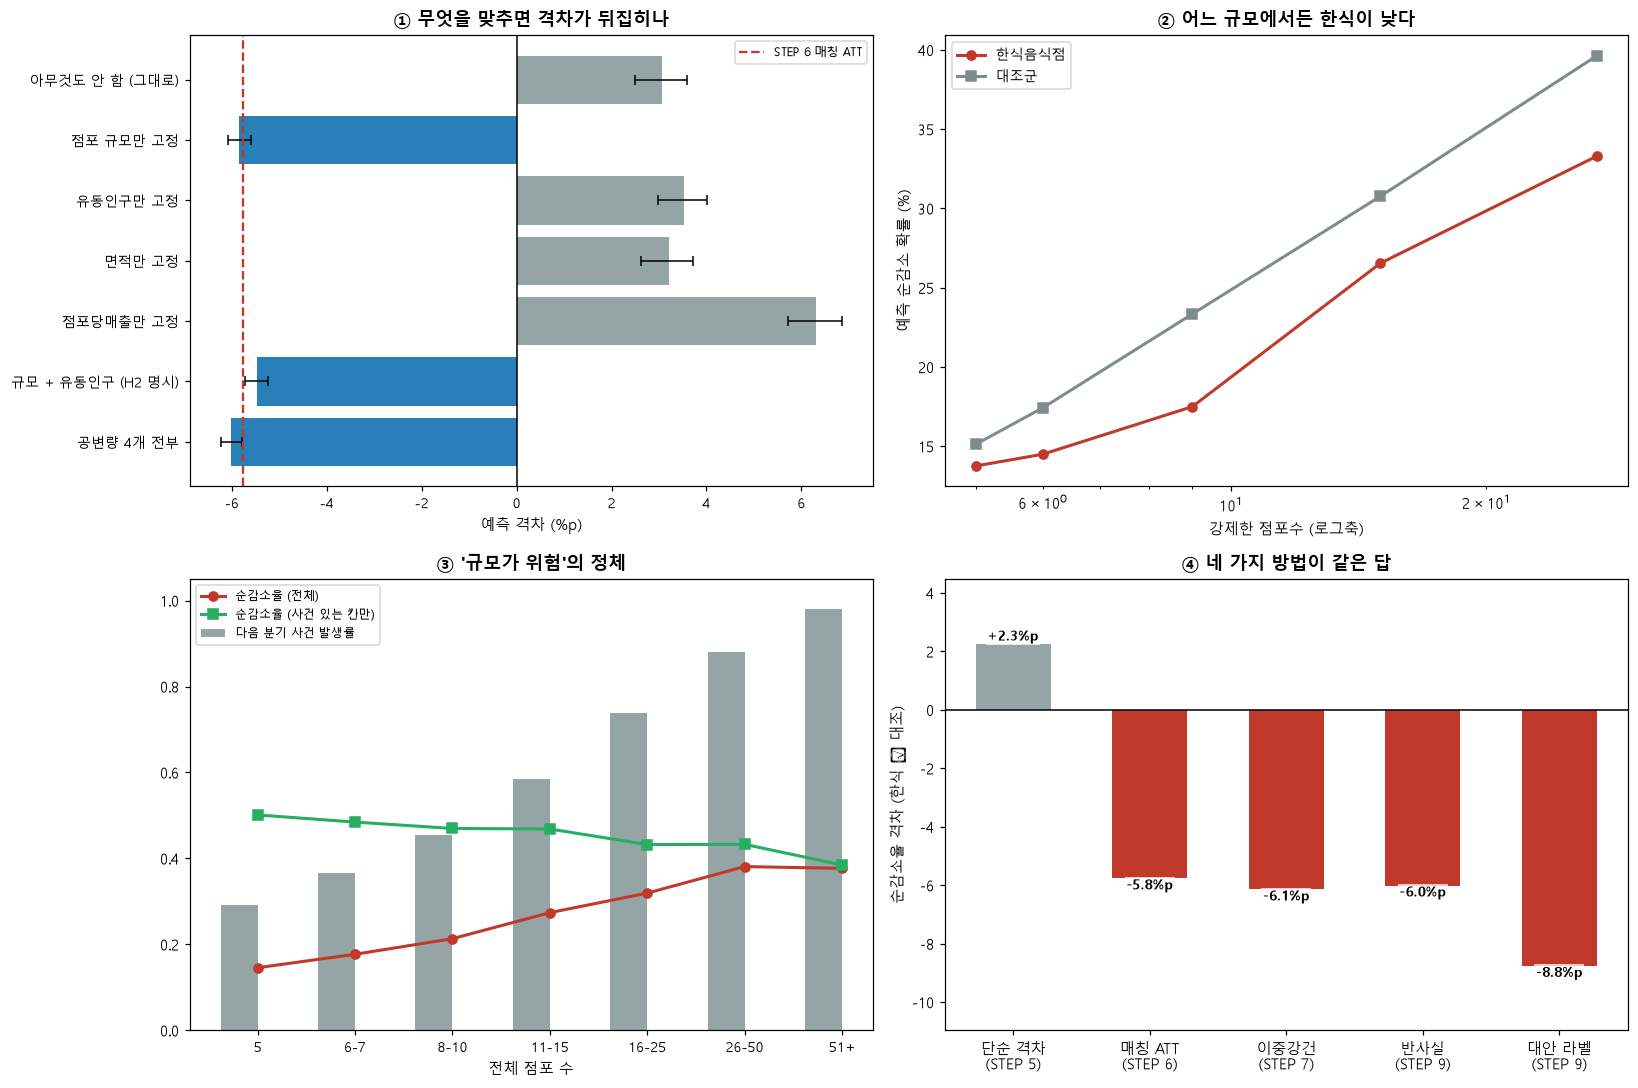

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# ① 반사실
c2 = cf.iloc[::-1]
colors = ["#2980b9" if v < 0 else "#95a5a6" for v in c2["예측격차"]]
ax[0,0].barh(c2["시나리오"], c2["예측격차"] * 100, color=colors,
             xerr=[(c2["예측격차"]-c2["CI_low"])*100, (c2["CI_high"]-c2["예측격차"])*100],
             error_kw=dict(ecolor="k", lw=1, capsize=3))
ax[0,0].axvline(0, c="k", lw=1)
ax[0,0].axvline(ATT6*100, ls="--", c="#c0392b", lw=1.5, label="STEP 6 매칭 ATT")
ax[0,0].set_xlabel("예측 격차 (%p)"); ax[0,0].tick_params(labelsize=9)
ax[0,0].set_title("① 무엇을 맞추면 격차가 뒤집히나", weight="bold"); ax[0,0].legend(fontsize=8)

# ② 용량-반응
ax[0,1].plot(dose["점포수"], dose[TREAT_SVC]*100, marker="o", lw=2, color="#c0392b", label=TREAT_SVC)
ax[0,1].plot(dose["점포수"], dose["대조군"]*100, marker="s", lw=2, color="#7f8c8d", label="대조군")
ax[0,1].set_xscale("log"); ax[0,1].set_xlabel("강제한 점포수 (로그축)")
ax[0,1].set_ylabel("예측 순감소 확률 (%)")
ax[0,1].set_title("② 어느 규모에서든 한식이 낮다", weight="bold"); ax[0,1].legend(fontsize=9)

# ③ 라벨 산술
x = np.arange(len(tbl)); w = 0.38
ax[1,0].bar(x - w/2, tbl["다음분기_사건발생률"], w, label="다음 분기 사건 발생률", color="#95a5a6")
ax[1,0].plot(x, tbl["순감소율_전체"], marker="o", color="#c0392b", lw=2, label="순감소율 (전체)")
ax[1,0].plot(x, tbl["순감소율_사건있는칸만"], marker="s", color="#27ae60", lw=2,
             label="순감소율 (사건 있는 칸만)")
ax[1,0].set_xticks(x); ax[1,0].set_xticklabels(tbl.index, fontsize=9)
ax[1,0].set_xlabel("전체 점포 수"); ax[1,0].set_ylim(0, 1.05)
ax[1,0].set_title("③ '규모가 위험'의 정체", weight="bold"); ax[1,0].legend(fontsize=8)

# ④ 방법별 결론 수렴
labels = ["단순 격차\n(STEP 5)", "매칭 ATT\n(STEP 6)", "이중강건\n(STEP 7)",
          "반사실\n(STEP 9)", "대안 라벨\n(STEP 9)"]
vals = [obs, ATT6, ATT_DR,
        float(cf.loc[cf["시나리오"] == "공변량 4개 전부", "예측격차"].iloc[0]), att_alt]
cols_ = ["#95a5a6"] + ["#c0392b"]*4
bars = ax[1,1].bar(labels, np.array(vals)*100, color=cols_, width=.55)
ax[1,1].axhline(0, c="k", lw=1); ax[1,1].margins(y=.20)
for b_, v in zip(bars, vals):
    ax[1,1].text(b_.get_x()+b_.get_width()/2, v*100, f"{v:+.1%}p".replace("%p", "%p"),
                 ha="center", va="bottom" if v > 0 else "top", weight="bold", fontsize=9,
                 bbox=dict(fc="white", ec="none", alpha=.75, pad=1))
ax[1,1].set_ylabel("순감소율 격차 (한식 − 대조)")
ax[1,1].set_title("④ 네 가지 방법이 같은 답", weight="bold")

plt.tight_layout()
plt.savefig(FIG / "step9_conclusion.png", dpi=130)
plt.show()

## 9-6. 결론 저장

In [13]:
cf.to_csv(OUT / "h2_counterfactual.csv", index=False, encoding="utf-8-sig")
dose.to_csv(OUT / "h2_dose_response.csv", index=False, encoding="utf-8-sig")
tbl.to_csv(OUT / "q2_label_mechanics.csv", encoding="utf-8-sig")
print("[저장] outputs/h2_counterfactual.csv, h2_dose_response.csv, q2_label_mechanics.csv")
print("[저장] figures/step9_conclusion.png\n")

print("=" * 62)
print("H2 : 골목상권에서 순감소 위험이 높은 업종의 경우,")
print("     점포 규모와 유동인구를 맞추면 타 업종과 격차가 줄어들 것이다")
print("-" * 62)
print(f"  단순 격차           {obs:+.2%}p   (한식이 더 위험해 보임)")
print(f"  매칭 ATT (STEP 6)   {ATT6:+.2%}p   부호 역전")
print(f"  이중강건 (STEP 7)   {ATT_DR:+.2%}p")
print(f"  반사실   (STEP 9)   {cf.loc[cf['시나리오']=='공변량 4개 전부','예측격차'].iloc[0]:+.2%}p")
print(f"  대안 라벨(STEP 9)   {att_alt:+.2%}p")
print()
print("  판정 : 부분 지지 — 격차가 '줄어드는' 게 아니라 '뒤집힙니다'.")
print("         단순 격차는 규모 교란의 산물이었고, 조건을 맞추면 한식이 더 안전합니다.")
print(f"  정밀화 : 역전을 만드는 것은 점포 규모 단독입니다"
      f" (규모만 고정 {cf.loc[cf['시나리오']=='점포 규모만 고정','예측격차'].iloc[0]:+.2%}p,"
      f" 유동인구만 고정 {cf.loc[cf['시나리오']=='유동인구만 고정','예측격차'].iloc[0]:+.2%}p).")
print("           H2 가 지목한 두 변수 중 실제로 작동하는 것은 하나뿐입니다.")
print()
print("=" * 62)
print("보조질문 2 : 어떤 특성이 다음 분기 순감소 전환과 관련되는가")
print("-" * 62)
print("  1위  점포 규모   AME +14.3%p / 순열 중요도 0.162 — 압도적")
print("       ※ 단, 상당 부분이 라벨 산술. 사건이 있었던 칸만 보면 규모가 클수록 오히려 낮음")
print("  2위  점포당매출  AME  -2.2%p / 순열 0.006 — 유의하나 규모의 1/28")
print("  3위  유동인구    AME  +0.7%p (p=0.078) — 점포수를 통제하면 사라짐(매개)")
print("       ※ 점포 밀도는 별개 특성이 아님 — 절대 점포수가 작동")
print("  업종 효과 : 공변량 통제 시 한식이 10개 업종 중 가장 안전 (9개 더미 전부 +, p<0.001)")
print("=" * 62)

[저장] outputs/h2_counterfactual.csv, h2_dose_response.csv, q2_label_mechanics.csv
[저장] figures/step9_conclusion.png

H2 : 골목상권에서 순감소 위험이 높은 업종의 경우,
     점포 규모와 유동인구를 맞추면 타 업종과 격차가 줄어들 것이다
--------------------------------------------------------------
  단순 격차           +2.27%p   (한식이 더 위험해 보임)
  매칭 ATT (STEP 6)   -5.76%p   부호 역전
  이중강건 (STEP 7)   -6.14%p
  반사실   (STEP 9)   -6.01%p
  대안 라벨(STEP 9)   -8.76%p

  판정 : 부분 지지 — 격차가 '줄어드는' 게 아니라 '뒤집힙니다'.
         단순 격차는 규모 교란의 산물이었고, 조건을 맞추면 한식이 더 안전합니다.
  정밀화 : 역전을 만드는 것은 점포 규모 단독입니다 (규모만 고정 -5.84%p, 유동인구만 고정 +3.53%p).
           H2 가 지목한 두 변수 중 실제로 작동하는 것은 하나뿐입니다.

보조질문 2 : 어떤 특성이 다음 분기 순감소 전환과 관련되는가
--------------------------------------------------------------
  1위  점포 규모   AME +14.3%p / 순열 중요도 0.162 — 압도적
       ※ 단, 상당 부분이 라벨 산술. 사건이 있었던 칸만 보면 규모가 클수록 오히려 낮음
  2위  점포당매출  AME  -2.2%p / 순열 0.006 — 유의하나 규모의 1/28
  3위  유동인구    AME  +0.7%p (p=0.078) — 점포수를 통제하면 사라짐(매개)
       ※ 점포 밀도는 별개 특성이 아님 — 절대 점포수가 작동
  업종 효과 : 공변량 통제 시 한식이 10개 업종 중 가장 안

---

## 남은 것

- **핵심 질문**(자치구별 순감소 전환 업종)은 다른 팀원 담당이라 여기서 다루지 않았습니다. 넘겨드릴 만한 것 하나 — STEP 8 의 8-7 절입니다. 자치구 × 업종 단위는 **단일 분기로는 검증 자체가 불가능**하고(목표값 반분 신뢰도 +0.035), 여러 분기를 모아야 평가할 수 있습니다
- **H1** 은 이 파이프라인에서 검증하지 않았습니다. STEP 4 의 상권유형 × 업종 교차표가 기술 통계로 남아 있습니다
- 개선 여지 — `01_flow.pkl` 의 시간대·연령대별 유동인구는 아직 미사용입니다. 외식업에는 총량보다 나은 신호일 수 있습니다
